# 3 输入部分实现

学习目标
- 了解文本嵌入层和位置编码的作用。
- 掌握文本嵌入层和位置编码的实现过程。

## 1 输入部分介绍

输入部分包含：
- 源文本嵌入层及其位置编码器
- 目标文本嵌入层及其位置编码器

## 💡 第一性原理：输入部分的两个组件为什么缺一不可？

### 问题1：没有 Embedding 会怎样？
计算机只认识数字。词在输入前是整数编号（如"我"=100），直接喂给网络，网络无法理解100和101之间有什么语义关系。Embedding 把每个词映射到一个**高维语义空间**，让语义相近的词在空间中距离近。

### 问题2：没有位置编码会怎样？
Transformer 的注意力机制是**并行的**——所有词同时处理。这意味着：
```
"我爱你" 和 "你爱我" → 对注意力机制来说完全相同！
```

因为注意力只看词之间的语义相似度，不关心顺序。**位置编码就是给每个位置打上一个独特的"时间戳"**，让网络知道谁先谁后。

### 费曼类比

```
Embedding   = 给每个人一个身份牌（"我是名词"、"我代表积极情感"）
位置编码    = 给每个人一个座位号（"我是第3个词"）
        
两者相加  = 网络同时知道"你是谁"和"你在哪"
```

### 🏢 更直观的类比：公司人事系统

把 Transformer 想象成一家公司的人事管理系统：

**词嵌入 = 给每个员工分配工号**

```
自然语言（人话）          计算机语言（向量/工号）
─────────────────      ─────────────────────────
"美丽"  ────────→  [0.23, -0.76, 0.51, 0.19, ...]
"漂亮"  ────────→  [0.21, -0.72, 0.49, 0.17, ...]   ← 同义词，向量相近！
"丑陋"  ────────→  [-0.61, 0.33, -0.18, 0.88, ...]  ← 反义词，向量远离
```

- 公司不能靠"那个高高的、说话带东北口音的小张"来管理员工——必须给每个人一个**唯一的数字编号**
- 计算机也一样，不能直接理解"美丽"这个词，需要转成一组数字（向量）
- 更妙的是：**语义相近的词，向量也相近**——就像同部门的员工，工号前缀相同

**位置编码 = 给重名的人加上工号后缀**

```
"我 爱 你"  vs  "你 爱 我"

没有位置编码：
  "我" = [0.13, 0.45, ...]    ← 两个"我"完全相同！
  "你" = [0.72, -0.31, ...]   ← 两个"你"完全相同！
  → 网络眼里：这是一堆词的集合，毫无顺序可言

加上位置编码后：
  "我"(位置0) = [0.13, 0.45, ...] + [sin(0), cos(0), ...]   ← 工号001的我
  "你"(位置2) = [0.72, -0.31, ...] + [sin(2), cos(2), ...]   ← 工号003的你
  → 网络眼里：每个词都有独一无二的身份+位置标识
```

就像公司里有两个"张伟"，名字完全一样，但**工号不同**（ZHANG-001 vs ZHANG-003），HR系统就能区分。位置编码就是给同一个词在不同位置加上独一无二的"工号"。

> **一句话总结**：词嵌入把自然语言编码成计算机能识别的矩阵（= 给员工分配工号），位置编码给重名的人加上独一无二的位置标识（= 工号后缀），两者相加，Transformer 就同时知道了"你是谁"和"你在哪"。

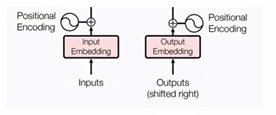

## 2 文本嵌入层的作用

- 无论是源文本嵌入还是目标文本嵌入，都是为了将文本中词汇的数字表示转变为向量表示，希望在这样的高维空间捕捉词汇间的关系。
- 文本嵌入层的代码分析：

In [2]:
import torch
import torch.nn as nn
import math
from torch.autograd import Variable

class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        """
        d_model: 词嵌入的维度（每个词用多少个数字表示）
                 Transformer论文中 d_model=512
        vocab:   词表的大小（语料库中共有多少个不同的词）
                 
        费曼类比: 
        - vocab = 字典里有多少个字
        - d_model = 每个字的解释用多少字来描述
        """
        super(Embeddings, self).__init__()
        # nn.Embedding 本质是一个巨大的查找表: (vocab, d_model)
        # 输入: 词的整数编号
        # 输出: 这个词对应的 d_model 维向量
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        """
        x: 词在词表中的整数编号，形状如 (batch, seq_len)
        
        为什么乘以 sqrt(d_model)?
        → 因为后面要和位置编码相加。位置编码使用 sin/cos 生成，
          数值范围在 [-1, 1]，如果 embedding 的值太小会被"淹没"。
          乘以 sqrt(d_model) 让两者在相近的数量级上。
        """
        return self.lut(x) * math.sqrt(self.d_model)

- nn.Embedding演示:

In [3]:
embedding = nn.Embedding(10, 3)
input = torch.LongTensor([[1,2,4,5],[4,3,2,9]])
embedding(input)
# tensor([[ 0.0251, -1.6902,  0.7172],
#     [-0.6431,  0.0748,  0.6969],
#     [ 1.4970,  1.3448, -0.9685],
#     [-0.3677, -2.7265, -0.1685]])

#     [[ 1.4970,  1.3448, -0.9685],
#     [ 0.4362, -0.4004,  0.9400],
#     [-0.6431,  0.0748,  0.6969],
#     [ 0.9124, -2.3616,  1.1151]])

embedding = nn.Embedding(10, 3, padding_idx=0)
input = torch.LongTensor([[0,2,0,5]])
embedding(input)
# tensor([[ 0.0000,  0.0000,  0.0000],
#     [ 0.1535, -2.0309,  0.9315],
#     [ 0.0000,  0.0000,  0.0000],
#     [-0.1655,  0.9897,  0.0635]])

tensor([[[ 0.0000,  0.0000,  0.0000],
         [ 0.7788, -0.2165, -0.3356],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.4428, -0.1471, -1.9680]]], grad_fn=<EmbeddingBackward0>)

- 实例化参数：

In [4]:
# 词嵌入维度是512维
d_model = 512
  
# 词表大小是1000
vocab = 1000

- 输入参数：

In [5]:
# 输入x是一个使用Variable封装的长整型张量，形状是2 x 4
x = Variable(torch.LongTensor([[100,2,421,508],[491,998,1,221]]))

- 调用

In [6]:
emb = Embeddings(d_model, vocab)
embr = emb(x)
print("embr:", embr)

embr: tensor([[[-17.3637, -13.7830,  -1.2821,  ...,  13.8697,   8.5775, -12.8880],
         [  2.2261,  -8.7865,  -8.8708,  ..., -64.8479,   1.3429, -26.9610],
         [-19.7418, -30.0709,  10.1602,  ...,  -2.3849, -27.2640,  18.9473],
         [ 14.1896,  11.8431, -26.7289,  ...,  -9.9676, -26.0826,  -7.9156]],

        [[-12.1609,   9.1921,  44.3495,  ..., -32.4794,  46.5515,  -9.7149],
         [-16.4670,  15.2619,  10.5497,  ..., -41.1800,  19.1410, -23.0083],
         [ -2.4195,  25.5292,  12.2466,  ...,  -9.1939, -19.3404,  -3.3017],
         [-20.0144,   5.0705,   1.2363,  ..., -35.0573, -45.3245,   2.3604]]],
       grad_fn=<MulBackward0>)


# 3 位置编码器的作用

因为在Transformer的编码器结构中，并没有针对词汇位置信息的处理，因此需要在Embedding层后加入位置编码器，将词汇位置不同可能会产生不同语义的信息加入到词嵌入张量中，以弥补位置信息的缺失。

## 3.1 位置编码器的代码分析

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        """
        d_model: 词嵌入维度（必须和Embedding的d_model一致！）
        dropout: 置0比率（防止过拟合）
        max_len: 支持的最大句子长度
        
        核心思想: 对每个位置pos和每个维度i，生成一个唯一的值:
          - 偶数维度(2i):   PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
          - 奇数维度(2i+1): PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
          
        为什么用sin/cos而不用简单的位置编号[0,1,2,...]?
        → sin/cos有界[-1,1]，不会随位置增长而爆炸
        → 不同频率的sin/cos叠加，使每个位置产生唯一"指纹"
        → 具有外推性: 模型能处理训练时未见过的更长序列
        """
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # 初始化位置编码矩阵: (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # position: [[0], [1], [2], ..., [max_len-1]]  形状 (max_len, 1)
        position = torch.arange(0, max_len).unsqueeze(1)

        # div_term: 对不同维度使用不同的频率
        # 低频(前几个维度)→位置变化缓慢, 捕捉全局位置
        # 高频(后几个维度)→位置变化快速, 捕捉局部位置
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (math.log(10000.0) / d_model)
        )

        # 偶数维度用sin, 奇数维度用cos
        pe[:, 0::2] = torch.sin(position * div_term)   # 偶数: 0, 2, 4, ...
        pe[:, 1::2] = torch.cos(position * div_term)   # 奇数: 1, 3, 5, ...

        # 增加batch维度: (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # register_buffer: 把pe注册为模型的一部分但不参与梯度更新
        # 因为位置编码是固定公式生成的，不需要学习
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: embedding后的张量, 形状 (batch, seq_len, d_model)
        
        把位置编码加到embedding上:
        x + pe → 每个词既有语义信息(embedding)又有位置信息(pe)
        """
        # self.pe[:, :x.size(1)]: 根据实际序列长度截取位置编码
        # requires_grad=False: 位置编码不参与梯度计算
        x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)
        return self.dropout(x)

- nn.Dropout演示:

In [8]:
m = nn.Dropout(p=0.2)
input = torch.randn(4, 5)
output = m(input)
output
# Variable containing:
#   0.0000 -0.5856 -1.4094  0.0000 -1.0290
#   2.0591 -1.3400 -1.7247 -0.9885  0.1286
#   0.5099  1.3715  0.0000  2.2079 -0.5497
# -0.0000 -0.7839 -1.2434 -0.1222  1.2815

# [torch.FloatTensor of size 4x5]

tensor([[ 1.4124, -1.1680,  0.4696,  0.0933,  0.1809],
        [-1.4347,  0.4342,  0.0000,  0.4658, -0.0092],
        [ 0.7047,  0.9167,  0.4753, -1.6704,  2.6717],
        [-0.0000,  0.0000,  0.6491, -1.5271,  1.1541]])

- torch.unsqueeze演示:

In [9]:
x = torch.tensor([1, 2, 3, 4])
torch.unsqueeze(x, 0)
# tensor([[ 1,  2,  3,  4]])
torch.unsqueeze(x, 1)
# tensor([[ 1],
#     [ 2],
#     [ 3],
#     [ 4]])

tensor([[1],
        [2],
        [3],
        [4]])

- 实例化参数:

In [10]:
# 调输入维度是512维
d_model = 512

# 置0比率为0.1
dropout = 0.1

# 句子最大长度
max_len=60

- 输入参数:

In [11]:
# 输入x是Embedding层的输出的张量，形状是2 x 4 x 512
x = emb

## 3.2 绘制词汇向量中特征的分布曲线

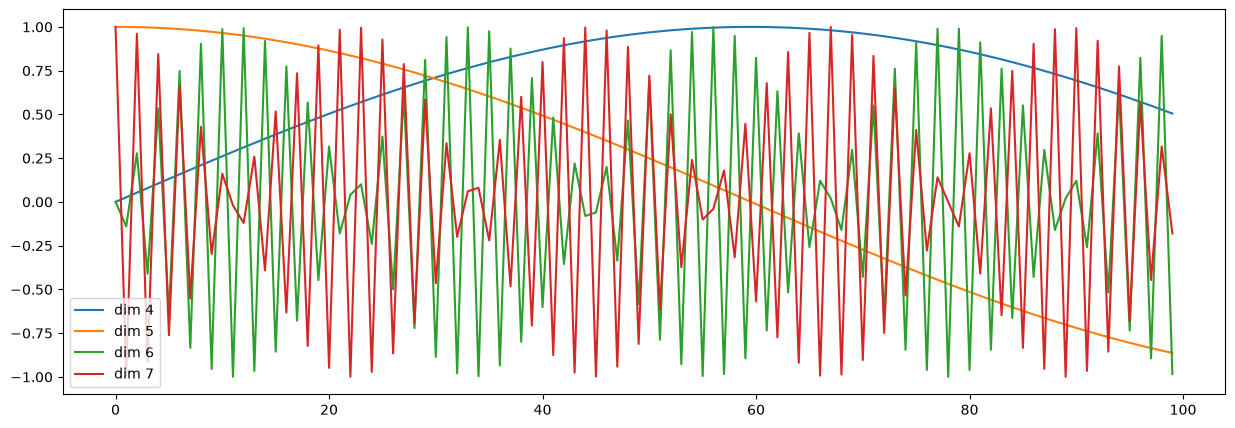

In [12]:
### 3.2 绘制词汇向量中特征的分布曲线

import matplotlib.pyplot as plt
import numpy as np

# 创建一张15 x 5大小的画布
plt.figure(figsize=(15, 5))

# 实例化PositionalEncoding类得到pe对象，输入参数是20和0
pe = PositionalEncoding(20, 0)

# 然后向pe传入被Variablel对象的tensor，这样ge会直接执行forward函数，
# 且这个tensor里的数值都是0，被处理后相当于位置编码张量
y = pe(Variable(torch.zeros(1, 100, 20)))

# 然后定义画布的横纵坐标，横坐标到100的长度，纵坐标是某一个词汇中的某维特征在不同长度下对应的值
# 因为总共20维之多，我们这里只查看4、5、6、7维的值。
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())

# 在画布上填写维度提示信息
plt.legend(["dim %d" % p for p in [4,5,6,7]])

---

## 📝 小结：一张图理解输入部分

### 核心问题

> **把一句话喂给 Transformer 之前，需要做哪些处理？**

答案是两件事：**Embedding（语义） + 位置编码（顺序）**

### 1. 文本嵌入层 — "这是什么词"

```
"我" → 100 → Embedding → [13.76, -17.76, 4.36, ..., -2.60]
```

把词的整数编号变成**稠密语义向量**。语义相近的词在向量空间中距离更近。

### 2. 位置编码器 — "这个词在哪"

```
位置0 → [sin(0),  cos(0),  sin(0/w),  cos(0/w),  ...]
位置1 → [sin(1),  cos(1),  sin(1/w),  cos(1/w),  ...]
位置2 → [sin(2),  cos(2),  sin(2/w),  cos(2/w),  ...]
```

**为什么不加位置编码不行？** Transformer 是并行处理所有词的——如果不加位置信息：

```
"我爱你" 和 "你爱我" → 对注意力机制来说完全相同！
```

加了位置编码后，"我"在位置0和"我"在位置2有了不同的向量。

**为什么用 sin/cos 而不用 [0,1,2,...]？**

| 方法 | 问题 |
|------|------|
| [0,1,2,...] | 数值会随句子变长而爆炸，且无法处理训练时没见过的长度 |
| sin/cos | 值永远在 [-1,1]，可以**外推**到更长的序列 |

### 完整数据流

```
输入: "我 爱 你"
         │
  ┌──────┴──────┐
  │             │
Embedding    位置编码
[13.76,...]  [0.00, 1.00, ...]   ← 位置0
[21.18,...]  [0.84, 0.54, ...]   ← 位置1
[28.60,...]  [0.91,-0.42, ...]   ← 位置2
  │             │
  └──────┬──────┘
         │ 相加
         ▼
 [13.76+0.00, ...]   ← "我"在位置0，有语义+有位次
 [21.18+0.84, ...]   ← "爱"在位置1
 [28.60+0.91, ...]   ← "你"在位置2
         │
         ▼
    送入编码器
```

> **一句话**：Embedding 告诉网络"这是什么词"，位置编码告诉网络"这个词在哪"。两者相加，就是 Transformer 能理解的一切。